# Figures

Generates every figure from the prepared data in `figure_data/` (one CSV file per data-driven figure,
produced from the raw simulation output of `two-pop-neural-net-homeo-hebb-plasticity.cc` by
`extract_figure_data.py`). The *Network* and *Structural plasticity* figures need no data files.
Figures are saved to `figures/`.

Run the cells top to bottom: some cells change global matplotlib settings that later cells inherit.
Requires numpy, pandas, matplotlib, networkx and a LaTeX installation (`usetex=True`).

In [1]:
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.axes as ax
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FormatStrFormatter
from matplotlib.lines import Line2D
import matplotlib.mlab as mlab
import matplotlib.ticker as mticker
import os

mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
plt.rc('text', usetex=True) ## this line is necessary to use the correct fonts 
plt.rc('font', family='serif') # this line is necessary to use the correct font

# This function makes the plots pretty 
def plot_prop(f1,ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left') 
    ax.xaxis.set_ticks_position('bottom')
    ax.spines['left'].set_position(('axes', -0.02))
    ax.spines['bottom'].set_position(('axes', -0.02))
    ax.xaxis.set_minor_locator(AutoMinorLocator(1))
    ax.yaxis.set_minor_locator(AutoMinorLocator(1))
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%g'))
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%g'))
    plt.tick_params(direction='out',which='major', length=10,width=1.5,colors='k',labelsize=f1)
    plt.tick_params(direction='out',which='minor',length=5,width=1, color='k')
    return;

In [2]:
import pandas as pd

FIGURE_DATA_DIR = "figure_data"   # prepared data: one CSV file per figure (see extract_figure_data.py)
FIGURE_DIR = "figures"            # figures are saved here
os.makedirs(FIGURE_DIR, exist_ok=True)


def read_figure_data(name):
    """Read figure_data/<name>.csv; the '#' lines at the top of each file describe its content."""
    return pd.read_csv(os.path.join(FIGURE_DATA_DIR, name + ".csv"), comment="#",
                       float_precision="round_trip")


def bin_edges_from_columns(bin_columns):
    """Histogram bin edges from bin column names of the form '[lo,hi)'."""
    lo = [float(c[1:-1].split(",")[0]) for c in bin_columns]
    hi = float(bin_columns[-1][1:-1].split(",")[1])
    return np.array(lo + [hi])


# raw-file column index -> column name in the time-trace CSV files
TRACE_COLUMNS = {0: "odpr_1", 1: "fi_mean_1", 2: "Avg_W_1", 3: "node_degree_density_1",
                 9: "Avg_W_1to2", 10: "node_degree_density_1to2",
                 11: "Avg_W_2to1", 12: "node_degree_density_2to1"}


def trace_array(df, variant, p_cross_pop0):
    """Time traces of one run as an array whose column c holds the measure saved in
    column c of the raw STDP+SP(...).dat file (columns that are not plotted are NaN)."""
    sel = df[(df["variant"] == variant) & np.isclose(df["p_cross_pop0"], p_cross_pop0)].sort_values("row_index")
    d = np.full((len(sel), 13), np.nan)
    for col, name in TRACE_COLUMNS.items():
        d[:, col] = sel[name].to_numpy()
    return d

## Network

Total connections: 37675
Intra-population density (pop1): 0.0700
Intra-population density (pop2): 0.0700


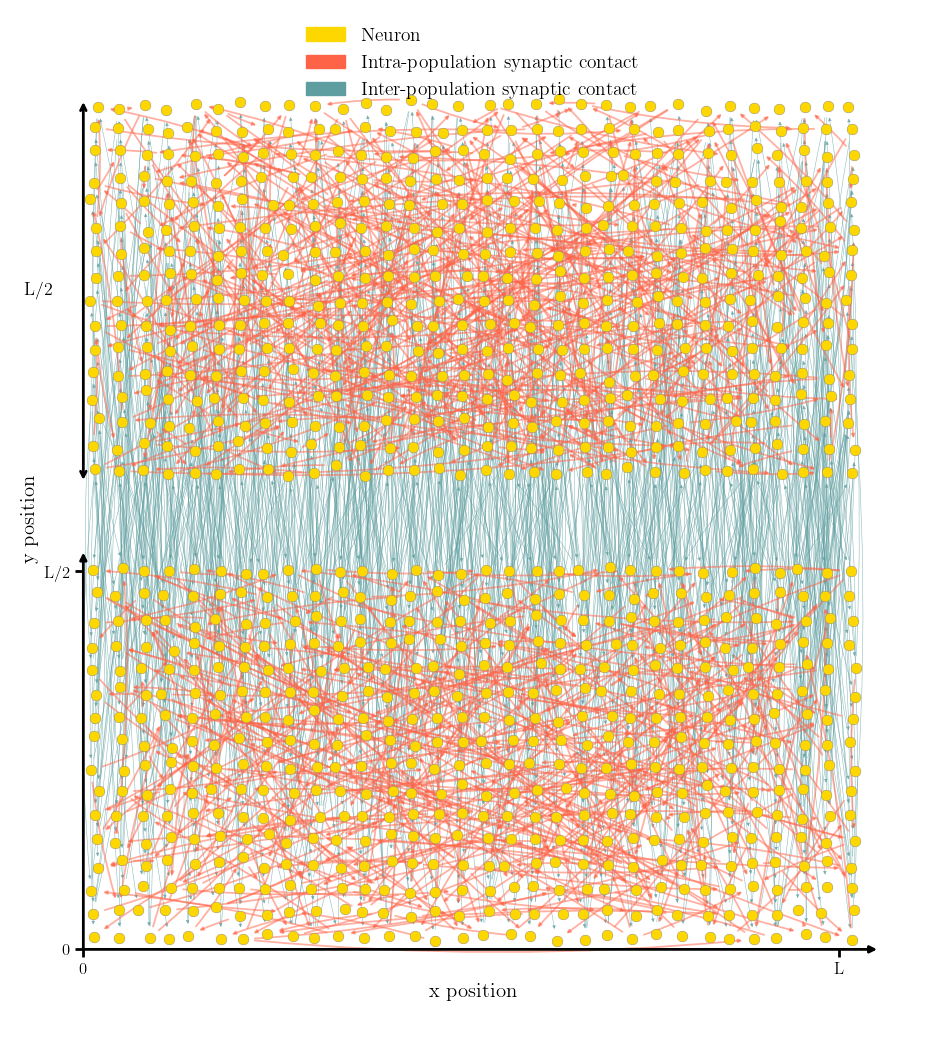

(<Figure size 1200x1050 with 1 Axes>,
 <Axes: xlabel='x position', ylabel='y position'>)

In [3]:
"""
Python translation of the network-geometry / connectivity C++ routines
(initialize_network_geometry, Dist_Dep_Adjacency_Matrix,
add_cross_population_connections), plus a script that builds a two-population
LIF network and a networkx-based illustration of it.

Conventions carried over from the C++ source:
  - A[i][j] == 1 means a directed connection j -> i (pre-synaptic j, post-synaptic i).
  - Neurons [0, N_pop) belong to population 1, [N_pop, N) to population 2.
  - `network_dimensions` is the side length of the square spatial domain that
    both populations jointly tile; the grid is split along y so each
    population occupies an L x (L/2) rectangle within that L x L square.
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ---------------------------------------------------------------------------
# 1. Neuron placement + distance / distance-kernel matrices
# ---------------------------------------------------------------------------
def initialize_network_geometry(rng, N, m, network_dimensions, y_gap=0.0):
    """
    Places N neurons on an m x m jittered grid spanning a square domain of
    side `network_dimensions`, then computes pairwise distances (Dd) and a
    same-population distance kernel (Zd = exp(-d / dst), dst = 0.25 * L).

    rng: a numpy.random.Generator (used in place of the C++ Ran RNG).
    y_gap: extra vertical offset added to population 2's y-coordinates, to
        create visible empty space between the two populations. Does not
        affect intra-population distances (rigid shift) or cross-population
        connectivity (which depends only on xi).
    Returns: xi, yi (shape (N,)), Zd, Dd (shape (N, N)).
    """
    hr = network_dimensions / (m - 1)
    dst = 0.25 * network_dimensions

    xi = np.zeros(N)
    yi = np.zeros(N)

    for i in range(N):
        un = rng.random()
        vn = rng.random()
        jitter_x = hr / 10.0 * np.sqrt(-2 * np.log(un)) * np.cos(2 * np.pi * vn)
        jitter_y = hr / 10.0 * np.sqrt(-2 * np.log(un)) * np.sin(2 * np.pi * vn)
        xi[i] = np.fmod(i + 0.5, m) * hr + jitter_x
        yi[i] = (0.5 + i // m) * hr + jitter_y

    N_half = N // 2
    yi[N_half:] += y_gap

    Zd = np.zeros((N, N))
    Dd = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            dij = np.sqrt((xi[i] - xi[j]) ** 2 + (yi[i] - yi[j]) ** 2)
            Dd[i, j] = dij
            same_pop = (i < N_half) == (j < N_half)
            if same_pop:
                Zd[i, j] = np.exp(-dij / dst)

    return xi, yi, Zd, Dd



# ---------------------------------------------------------------------------
# 2. Distance-dependent adjacency within each population
# ---------------------------------------------------------------------------
def dist_dep_adjacency_matrix(p, Zd, number, N, N_pop, seed_multiplier=1000):
    """
    Builds an N x N adjacency matrix with intra-population connections only,
    added with probability proportional to p * Zd[i][j] until the target
    density p is reached (per population), matching the C++ rejection loop.
    """
    matrix = np.zeros((N, N))
    seed_ = seed_multiplier * number
    rng = np.random.default_rng(seed_)
    max_edges = N_pop * (N_pop - 1)

    for pop_start in (0, N_pop):
        pop_end = pop_start + N_pop
        neuron_indices = np.arange(pop_start, pop_end)
        ncon = 0
        while p - ncon / float(max_edges) > 0.001:
            rng.shuffle(neuron_indices)
            for i in neuron_indices:
                for j in range(pop_start, pop_end):
                    rnd = rng.random()
                    if i != j and matrix[i, j] == 0 and rnd < p * Zd[i, j]:
                        matrix[i, j] = 1
                        ncon += 1
                if ncon > p * max_edges:
                    break

    return matrix


# ---------------------------------------------------------------------------
# 3. Cross-population connections
# ---------------------------------------------------------------------------
def add_cross_population_connections(A, p_cross, number, xi, network_dimensions,
                                      N, N_pop, seed_multiplier=10000):
    """
    Adds directed cross-population connections in place. For each post-neuron
    in one population, n_connect = int(p_cross * N_pop) pre-neurons are drawn
    (without replacement) from the other population, restricted to candidates
    within x_threshold = 0.1 * network_dimensions in x-position.
    """
    rng = np.random.default_rng(seed_multiplier * number)
    x_threshold = 0.1 * network_dimensions
    n_connect = int(p_cross * N_pop)

    # Pop1 -> Pop2: post neurons in pop2, pre candidates in pop1
    for i in range(N_pop, N):
        candidates = [j for j in range(N_pop) if abs(xi[i] - xi[j]) <= x_threshold]
        rng.shuffle(candidates)
        n = min(n_connect, len(candidates))
        for k in range(n):
            A[i, candidates[k]] = 1

    # Pop2 -> Pop1: post neurons in pop1, pre candidates in pop2
    for i in range(N_pop):
        candidates = [j for j in range(N_pop, N) if abs(xi[i] - xi[j]) <= x_threshold]
        rng.shuffle(candidates)
        n = min(n_connect, len(candidates))
        for k in range(n):
            A[i, candidates[k]] = 1

    return A


# ---------------------------------------------------------------------------
# 4. Illustration
# ---------------------------------------------------------------------------
def visualize_network(A, xi, yi, N_pop, network_dimensions, y_gap, figsize=(12, 10.5), node_size=60,
                       max_edges_per_type=1000, seed=0, save_path=None):

    N = A.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    intra_edges = []
    inter_edges = []
    rows, cols = np.nonzero(A)
    for i, j in zip(rows, cols):
        edge = (j, i)
        same_pop = (i < N_pop) == (j < N_pop)
        (intra_edges if same_pop else inter_edges).append(edge)

    rng = np.random.default_rng(seed)
    if max_edges_per_type is not None:
        if len(intra_edges) > max_edges_per_type:
            idx = rng.choice(len(intra_edges), max_edges_per_type, replace=False)
            intra_edges = [intra_edges[k] for k in idx]
        if len(inter_edges) > max_edges_per_type:
            idx = rng.choice(len(inter_edges), max_edges_per_type, replace=False)
            inter_edges = [inter_edges[k] for k in idx]

    G.add_edges_from(intra_edges)
    G.add_edges_from(inter_edges)

    pos = {k: (xi[k], yi[k]) for k in range(N)}

    NEURON_COLOR = "gold"
    INTRA_COLOR = "tomato"
    INTER_COLOR = "#5F9EA0"

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(
        G, pos, node_color=NEURON_COLOR, node_size=node_size,
        edgecolors="gray", linewidths=0.3, node_shape="o", ax=ax,
    )
    nx.draw_networkx_edges(
        G, pos, edgelist=inter_edges, edge_color=INTER_COLOR,
        arrows=True, arrowsize=5, width=0.4, alpha=0.7,
        connectionstyle="arc3,rad=0.05", ax=ax,
    )
    nx.draw_networkx_edges(
        G, pos, edgelist=intra_edges, edge_color=INTRA_COLOR,
        arrows=True, arrowsize=5, width=1.3, alpha=0.5,
        connectionstyle="arc3,rad=0.05", ax=ax,
    )

    L = network_dimensions

    legend_handles = [
        mpatches.Patch(color=NEURON_COLOR, label="Neuron"),
        mpatches.Patch(color=INTRA_COLOR, label="Intra-population synaptic contact"),
        mpatches.Patch(color=INTER_COLOR, label="Inter-population synaptic contact"),
    ]
    ax.legend(handles=legend_handles, loc="upper center", frameon=False, prop={'family': 'serif', 'size': 14})

    ax.set_xlabel("x position", fontsize=15, fontname='serif')
    ax.set_ylabel("y position", fontsize=15, fontname='serif')
    ax.set_aspect("equal")

    pad = 0.0  # gap between the network and the axes/arrow

    # Keep left/bottom spines only for their color/width and tick anchoring;
    # hide the plain line since arrowed versions are drawn below.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_position(("data", -pad))
    ax.spines["bottom"].set_position(("data", -pad))
    ax.spines["left"].set_bounds(-pad, L / 2)
    ax.spines["bottom"].set_bounds(-pad, L)
    axis_color = ax.spines["left"].get_edgecolor()
    axis_lw = ax.spines["left"].get_linewidth()
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Ticks only at the endpoints, labeled 0/L (x) and 0/L/2 (y).
    ax.set_xticks([0, L])
    ax.set_xticklabels(["0", "L"], fontsize=12, fontname="serif")
    ax.set_yticks([0, L / 2])
    ax.set_yticklabels(["0", "L/2"], fontsize=12, fontname="serif")

    # Force the tick marks/labels to actually render, since the bottom/left
    # spines they'd normally hang off of are hidden above.
    ax.tick_params(axis="x", which="both", bottom=True, top=False,
                    labelbottom=True, length=6, width=axis_lw, color=axis_color)
    ax.tick_params(axis="y", which="both", left=True, right=False,
                    labelleft=True, length=6, width=axis_lw, color=axis_color)


    # Make sure the padded axes aren't clipped by the autoscaled view.
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_xlim(min(xlim[0], -pad * 1.5), xlim[1])
    ax.set_ylim(min(ylim[0], -pad * 1.5), ylim[1])

    # x-axis, drawn as an arrow from the origin out to L
    ax.annotate(
        "", xy=(L+0.1, -pad), xytext=(-pad, -pad),
        arrowprops=dict(arrowstyle="-|>", color=axis_color,
                         linewidth=axis_lw, shrinkA=0, shrinkB=0),
        annotation_clip=False,
    )
    # y-axis, drawn as an arrow from the origin out to L/2
    ax.annotate(
        "", xy=(-pad, L / 2 + 0.05), xytext=(-pad, -pad),
        arrowprops=dict(arrowstyle="-|>", color=axis_color,
                         linewidth=axis_lw, shrinkA=0, shrinkB=0),
        annotation_clip=False,
    )

    # Double-headed arrow marking the L/2 vertical extent of the upper
    # subpopulation, offset by `pad`, aligned in x with the y-axis above.
    y_lo = L / 2 + 1.21 * y_gap
    y_hi = L + 1.21 * y_gap
    ax.annotate(
        "", xy=(-pad, y_hi), xytext=(-pad, y_lo),
        arrowprops=dict(arrowstyle="<->", color=axis_color,
                         linewidth=axis_lw, shrinkA=0, shrinkB=0),
        annotation_clip=False,
    )
    ax.text(-pad - 0.04 * L, (y_lo + y_hi) / 2, "L/2",
            ha="right", va="center", fontsize=13, fontname="serif",
            color=axis_color)


    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

    return fig, ax


# ---------------------------------------------------------------------------
# Script: build the network and illustrate it
# ---------------------------------------------------------------------------
N = 1024
N_pop = N // 2                 # 512 neurons per population
m = int(round(np.sqrt(N)))     # 32x32 placement grid
L = 2.0                        # network_dimensions; each population
                                # occupies an L x (L/2) rectangle, stacked
                                # along y to fill the L x L domain
network_dimensions = L
y_gap = 0.2                    # empty vertical space between the two
                                # populations, in same units as network_dimensions;
                                # increase/decrease this to change the gap

p_intra = 0.07
p_cross = 0.002
number = 1                     # seed index, mirrors C++ `number` arg

rng = np.random.default_rng(42)
xi, yi, Zd, Dd = initialize_network_geometry(rng, N, m, network_dimensions, y_gap=y_gap)

A = dist_dep_adjacency_matrix(p_intra, Zd, number, N, N_pop)
A = add_cross_population_connections(
    A, p_cross, number, xi, network_dimensions, N, N_pop
)

print(f"Total connections: {int(A.sum())}")
print(f"Intra-population density (pop1): "
        f"{A[:N_pop, :N_pop].sum() / (N_pop * (N_pop - 1)):.4f}")
print(f"Intra-population density (pop2): "
        f"{A[N_pop:, N_pop:].sum() / (N_pop * (N_pop - 1)):.4f}")

visualize_network(A, xi, yi, N_pop, network_dimensions, y_gap,save_path="figures/Network.jpeg")


## Initial Connectivity

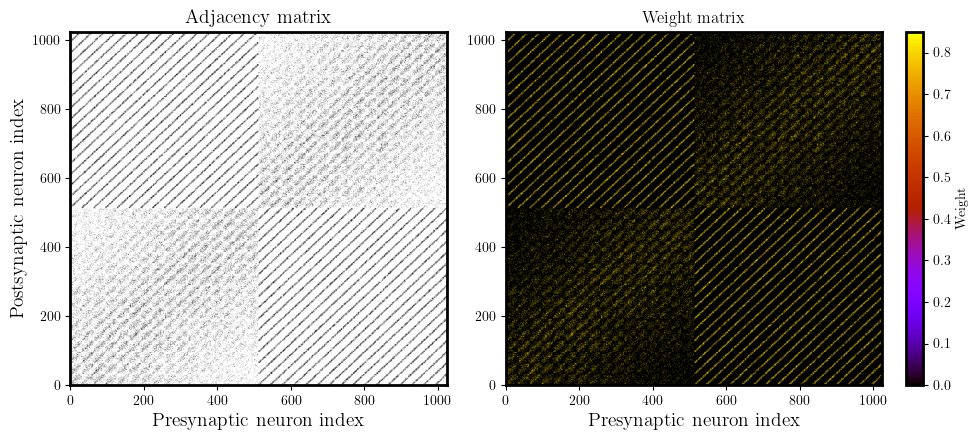

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

f1 = 14
# initial weight matrix (A*W), stored as its nonzero (post, pre, weight) entries; N = 1024 neurons
W_entries = read_figure_data("adjacency_matrix")
W = np.zeros((1024, 1024))
W[W_entries["post"].to_numpy(), W_entries["pre"].to_numpy()] = W_entries["weight"].to_numpy()
N2,N = W.shape
A = np.zeros([N2,N])
A[np.where(W!=0)] = 1

fig = plt.figure(figsize=(10, 4.5))
gs = GridSpec(1, 2, figure=fig, width_ratios=[0.8,1])

ax1 = fig.add_subplot(gs[0]) 
ax2 = fig.add_subplot(gs[1]) 

# Plot the adjacency matrix 
im1 = ax1.imshow(A[:N,:], cmap='Grays', aspect='auto',origin='lower')
ax1.set_title('Adjacency matrix', fontsize=f1)
ax1.set_xlabel('Presynaptic neuron index', fontsize=f1)
ax1.set_ylabel('Postsynaptic neuron index', fontsize=f1)
# fig.colorbar(im1, ax=ax1, label='Value')

# Plot the weight matrix on 
im2 = ax2.imshow(W[:N,:], cmap='gnuplot', aspect='auto',origin='lower')
ax2.set_title('Weight matrix')
ax2.set_xlabel('Presynaptic neuron index', fontsize=f1)
fig.colorbar(im2, ax=ax2, label='Weight')

plt.tight_layout()
plt.savefig("figures/adjacency_matrix.jpeg", dpi=300)
plt.show()


## Structural plasticity

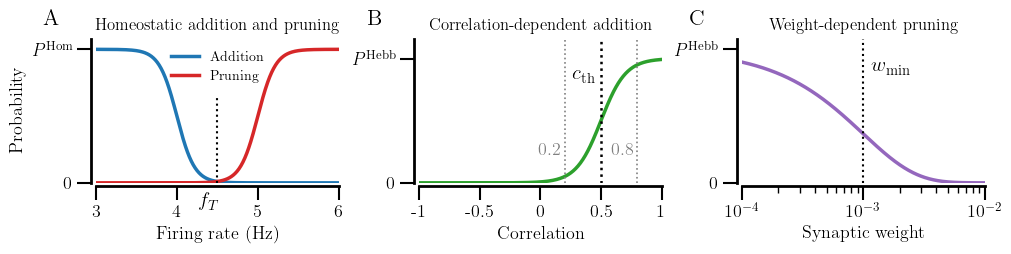

In [5]:
"""
Generate a 3-panel figure showing the structural plasticity probability
equations:

Panel 1: Homeostatic addition & pruning probability vs firing rate f_i
Panel 2: Correlation-dependent (Hebbian) addition probability vs c_ij
Panel 3: Weight-dependent (Hebbian) pruning probability vs w_ij
"""

# -----------------------------------------------------------------------
# Global parameters
# -----------------------------------------------------------------------

# --- Homeostatic addition/pruning (Panel 1) ---
f_T = 4.5          # Hz, homeostatic set point
delta_f = 1.0       # Hz, steepness parameter
p_T_tilde = 0.01    # baseline probability at the set point

f_minus = f_T - delta_f / 2.0   # midpoint for addition curve
f_plus = f_T + delta_f / 2.0    # midpoint for pruning curve
nu = delta_f / (2.0 * np.log((1 - p_T_tilde) / p_T_tilde))

P_Hom = 1.0   # maximal homeostatic probability (plotted, but labeled P^Hom)

# l_ij dependence set to 1 (l_ij = 0, so exp(-l_ij/l0) = 1)
exp_distance_term = 1.0

# --- Correlation-dependent (Hebbian) addition (Panel 2) ---
c_th = 0.5
nu_c = 0.102
P_Hebb = 1.0  # maximal Hebbian probability (plotted, but labeled P^Hebb)

# --- Weight-dependent (Hebbian) pruning (Panel 3) ---
w_min = 0.001

# -----------------------------------------------------------------------
# Function definitions
# -----------------------------------------------------------------------

def G(Omega, Omega0, nu_):
    """Logistic function."""
    return 1.0 / (1.0 + np.exp(-(Omega - Omega0) / nu_))


def P_add_hom(f_i):
    """Homeostatic addition probability (as a function of f_i only,
    since exp(-l_ij/l0) is fixed to 1)."""
    return P_Hom * G(f_i, f_minus, -nu) * exp_distance_term


def P_prn_hom(f_i):
    """Homeostatic pruning probability."""
    return P_Hom * G(f_i, f_plus, nu)


def P_add_hebb(c_ij):
    """Correlation-dependent (Hebbian) addition probability."""
    return P_Hebb / (1.0 + np.exp(-(c_ij - c_th) / nu_c))


def P_prn_hebb(w_ij):
    """Weight-dependent (Hebbian) pruning probability."""
    return P_Hebb * np.exp(-w_ij / w_min)


# -----------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------

fig = plt.figure(constrained_layout=True)
fig.set_size_inches(10,2.4)  # the size of the plot in inches 
gs = gridspec.GridSpec(1, 3, figure=fig)
l1=1; f1=13; f2=12; f3=16  # the font sizes 

# ---------------- Panel 1: Homeostatic addition & pruning ----------------
ax = plt.subplot(gs[0])
plot_prop(f1,ax)

f_range = np.linspace(3, 6, 500)
add_curve = P_add_hom(f_range)
prn_curve = P_prn_hom(f_range)

ax.plot(f_range, add_curve, color="tab:blue", lw=2.5, label="Addition")
ax.plot(f_range, prn_curve, color="tab:red", lw=2.5, label="Pruning")

# mark f_T
ax.axvline(f_T, ymax=0.6, color="black", linestyle=":", lw=1.5)
ax.text(f_T, -0.2, r"$f_T$", ha="right", va="bottom", fontsize=15)
ax.text(-0.15, 1.2, "A", transform=ax.transAxes, fontsize=f3, fontweight="bold", va="top", ha="right")

ax.set_xlim(3, 6)
ax.set_ylim(0, 1.08)
ax.set_yticks([0, 1])
ax.set_yticklabels(["0", r"$P^\mathrm{Hom}$"])
ax.set_xlabel("Firing rate (Hz)", fontsize=f1)
ax.set_ylabel("Probability", fontsize=f1)
ax.set_title("Homeostatic addition and pruning")
ax.legend(loc="upper center", frameon=False)

# ---------------- Panel 2: Correlation-dependent addition ----------------
ax = plt.subplot(gs[1])
plot_prop(f1,ax)
c_range = np.linspace(-1, 1, 500)
hebb_add_curve = P_add_hebb(c_range)

ax.plot(c_range, hebb_add_curve, color="tab:green", lw=2.5)

# mark c = 0.2 and c = 0.8 (lighter dotted lines)
for c_val in [0.2, 0.8]:
    ax.axvline(c_val, color="gray", linestyle=":", lw=1.2)
    ax.text(c_val - 0.03, 0.2, f"{c_val}", ha="right", va="bottom", fontsize=13, color="gray")

# mark c_th (darker dotted line)
ax.axvline(c_th, color="black", linestyle=":", lw=1.8)
ax.text(c_th-0.05, 0.8, r"$c_\mathrm{th}$", ha="right", va="bottom", fontsize=15)
ax.text(-0.15, 1.2, "B", transform=ax.transAxes, fontsize=f3, fontweight="bold", va="top", ha="right")

ax.set_xlim(-1, 1)
ax.set_ylim(0, 1.16)
ax.set_yticks([0, 1])
ax.set_yticklabels(["0", r"$P^\mathrm{Hebb}$"])
ax.set_xlabel("Correlation", fontsize=f1)
ax.set_title("Correlation-dependent addition")

# ---------------- Panel 3: Weight-dependent pruning ----------------
ax = plt.subplot(gs[2])
plot_prop(f1,ax)
w_range = np.logspace(-4, -2, 500)
hebb_prn_curve = P_prn_hebb(w_range)

ax.plot(w_range, hebb_prn_curve, color="tab:purple", lw=2.5)

# mark w_min
ax.axvline(w_min, color="black", linestyle=":", lw=1.5)
ax.text(w_min * 2.4, 0.8, r"$w_\mathrm{min}$", ha="right", va="bottom", fontsize=15)
ax.text(-0.15, 1.2, "C", transform=ax.transAxes, fontsize=f3, fontweight="bold", va="top", ha="right")

ax.set_xscale("log")
ax.set_xlim(1e-4, 1e-2)
ax.set_ylim(0, 1.08)
ax.set_yticks([0, 1])
ax.set_yticklabels(["0", r"$P^\mathrm{Hebb}$"])
ax.set_xlabel("Synaptic weight", fontsize=f1)
ax.set_title("Weight-dependent pruning")
plt.show()

# -----------------------------------------------------------------------
# Save outputs
# -----------------------------------------------------------------------
fig.savefig("figures/structural_plasticity_figure.jpeg", dpi=300, bbox_inches="tight")


## Spontaneous maps

************************* FOR CROSS_POPULATION CONNECTION PROBABILITY OF 0.1 *************************
************************* FOR CROSS AND SAME POPULATION DELAYS OF 10 ms AND 3 ms, RESPECTIVELY *************************


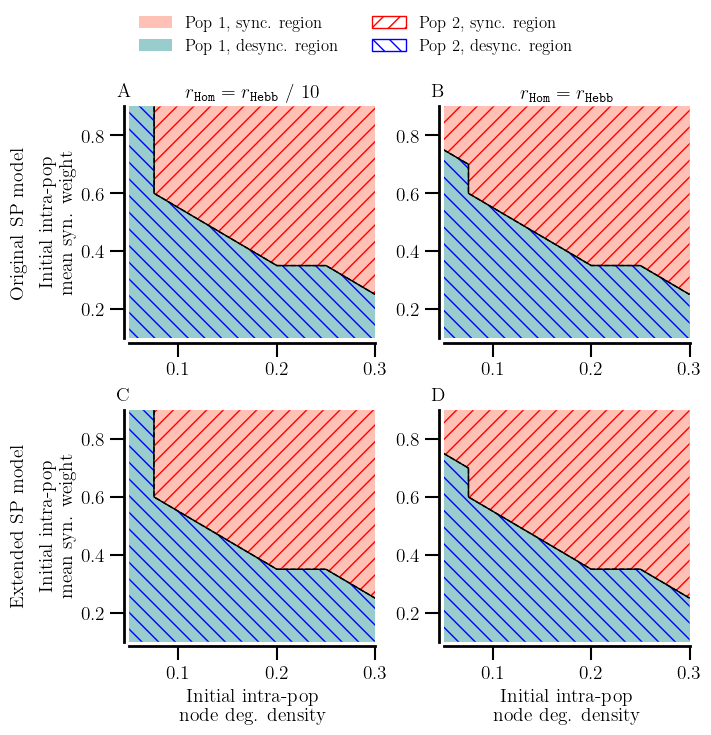

In [ ]:
from matplotlib.patches import Patch

asym_param = 1.4
mean_initial_w = np.arange(0.1,1.0,0.1)
mean_initial_ndd = np.arange(0.05,0.31,0.05)
p_cross_pop = 0.1  # cross-pop connection probability fixed at 0.1
cross_pop_delay = [10] 
same_pop_delay = [3] 

Nw = len(mean_initial_w)
Np = len(mean_initial_ndd)
N = 1024 # number of neurons
lw = 1
l1=1; f1=14; f2=12; f3=18  # the font sizes
# order parameters averaged over the last 5 hours are precomputed (see extract_figure_data.py)

spontaneous_maps = read_figure_data("spontaneous_maps_old_vs_new_SP")
folder_labels = {
    "HebHom3": r"$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
    "HebHom2": r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "Original1": r"$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
    "Original": r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
}

# rows top-to-bottom, each row left-to-right
row_layout = [["Original1", "Original"], ["HebHom3", "HebHom2"]]
row_labels = ["Original SP model", "Extended SP model"]
letters = [['A', 'B'], ['C', 'D']]

threshold = 0.5           # order parameter split between "red" (sync) and "blue" (desync) regions
alpha_pop1 = 0.4           # transparency for Pop1 solid fill
color_red, color_blue = 'tomato', 'teal'
hatch_color_red, hatch_color_blue = 'red', 'blue'
hatch_red, hatch_blue = '//', '\\\\'

def get_order_par_grids(key, pc, cpd, spd):
    # rows of one variant and p_cross, ordered Wmean-major / beta-minor (only cpd = 10 ms, spd = 3 ms data exist)
    sel = spontaneous_maps[(spontaneous_maps["variant"] == key)
                           & np.isclose(spontaneous_maps["p_cross_pop0"], pc)].sort_values(["Wmean", "beta"])
    return (sel["order_par_pop1"].to_numpy().reshape(Nw,Np),   # population 1
            sel["order_par_pop2"].to_numpy().reshape(Nw,Np))   # population 2

pc = p_cross_pop
print(f"************************* FOR CROSS_POPULATION CONNECTION PROBABILITY OF {pc} *************************")
for cpd, spd in zip(cross_pop_delay, same_pop_delay):
    print(f"************************* FOR CROSS AND SAME POPULATION DELAYS OF {cpd} ms AND {spd} ms, RESPECTIVELY *************************")

    P, W = np.meshgrid(mean_initial_ndd, mean_initial_w)

    fig, axes = plt.subplots(2, 2, figsize=(7,6.5), sharex=True, sharey=True,
                              constrained_layout=True)

    for row in range(2):
        for col in range(2):
            key = row_layout[row][col]
            ax = axes[row, col]
            plt.sca(ax)
            plot_prop(f1, ax)

            order_par0, order_par1 = get_order_par_grids(key, pc, cpd, spd)

            # Pop1: solid shaded area with solid boundary
            ax.contourf(P, W, order_par0, levels=[-np.inf, threshold, np.inf],
                        colors=[color_blue, color_red], alpha=alpha_pop1)
            ax.contour(P, W, order_par0, levels=[threshold], colors='k',
                       linestyles='solid', linewidths=lw)

            # Pop2: hatched area (no fill) with dashed boundary
            cs_red = ax.contourf(P, W, order_par1, levels=[threshold, np.inf],
                                  colors='none', hatches=[hatch_red])
            cs_blue = ax.contourf(P, W, order_par1, levels=[-np.inf, threshold],
                                   colors='none', hatches=[hatch_blue])
            for cs, hcolor in [(cs_red, hatch_color_red), (cs_blue, hatch_color_blue)]:
                artists = cs.collections if hasattr(cs, 'collections') else [cs]
                for c in artists:
                    c.set_edgecolor(hcolor)
                    c.set_facecolor('none')
                    c.set_linewidth(0.0)
            ax.contour(P, W, order_par1, levels=[threshold], colors='k',
                       linestyles='dashed', linewidths=lw)

            ax.text(-0.05, 1.1, letters[row][col], transform=ax.transAxes,
                    fontsize=f1, fontweight='bold', va='top', ha='left')
            if row == 0:
                ax.set_title(folder_labels[key], fontsize=f1)
            if row == 1:
                ax.set_xlabel('Initial intra-pop \nnode deg. density', fontsize=f1)
            if col == 0:
                ax.set_ylabel('Initial intra-pop \nmean syn. weight', fontsize=f1)

        axes[row, 0].annotate(row_labels[row], xy=(-0.45, 0.5), xycoords='axes fraction',
                               fontsize=f1, fontweight='bold', rotation=90, ha='center', va='center')

    legend_elements = [
        Patch(facecolor=color_red, alpha=alpha_pop1, label='Pop 1, sync. region'),
        Patch(facecolor=color_blue, alpha=alpha_pop1, label='Pop 1, desync. region'),
        Patch(facecolor='none', edgecolor=hatch_color_red, hatch=hatch_red, label='Pop 2, sync. region'),
        Patch(facecolor='none', edgecolor=hatch_color_blue, hatch=hatch_blue, label='Pop 2, desync. region'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2,
               bbox_to_anchor=(0.5, 1.12), fontsize=f2, frameon=False)

    plt.savefig("figures/spontaneous_maps_old_vs_new_SP.jpeg", dpi=300, bbox_inches='tight')
    plt.show()


## Dependence of regions of sync and desync on ratio of $r_\text{Hom}$ and $r_\text{Hebb}$ as well as initial inter-pop node degree density

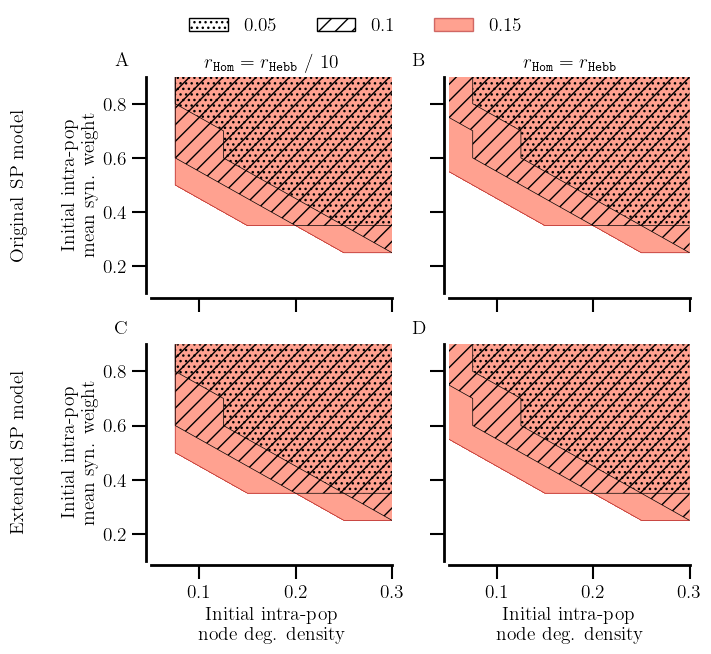

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

mean_initial_w = np.arange(0.1, 1.0, 0.1)
mean_initial_ndd = np.arange(0.05, 0.31, 0.05)
p_cross_pop = [0.05, 0.1, 0.15]
cross_pop_delay = 10
same_pop_delay = 3

P, W = np.meshgrid(mean_initial_ndd, mean_initial_w)
Nw = len(mean_initial_w)
Np = len(mean_initial_ndd)
f1 = 14

red_threshold = 0.5  # order parameter cutoff separating "red" from "blue" (bwr midpoint)

# order parameters averaged over the last 5 hours are precomputed (see extract_figure_data.py)

spontaneous_map_comparison = read_figure_data("spontaneous_map_comparison_old_vs_new_SP")
folder_label = {
    "Original1": r"$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
    "Original":  r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "HebHom3":   r"$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
    "HebHom2":   r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
}

# top row = original SP model, bottom row = extended model; columns aligned by r_Hom ratio
row_keys = [["Original1", "Original"], ["HebHom3", "HebHom2"]]
row_text = {0: "Original SP model", 1: "Extended SP model"}

# Plot order: largest red region first (base layer), then progressively smaller
# regions on top, each in a visually distinct style.
pc_sorted = sorted(p_cross_pop, reverse=True)
region_style = {
    pc_sorted[0]: dict(fill='tomato', hatch=None, edgecolor='firebrick', alpha=0.6),
    pc_sorted[1]: dict(fill='none',       hatch='//',  edgecolor='black',    alpha=1.0),
    pc_sorted[2]: dict(fill='none',       hatch='...', edgecolor='black',    alpha=1.0),
}

plt.rcParams['hatch.color'] = 'black'


def load_order_par(key, pc):
    # population 1 order parameter of one variant and p_cross, ordered Wmean-major / beta-minor
    df = spontaneous_map_comparison
    sel = df[(df["variant"] == key) & np.isclose(df["p_cross_pop0"], pc)].sort_values(["Wmean", "beta"])
    return sel["order_par_pop1"].to_numpy().reshape(Nw, Np)


fig, axes = plt.subplots(2, 2, figsize=(7, 6), constrained_layout=True, sharex=True, sharey=True)
panel_letters = ['A', 'B', 'C', 'D']
letter_idx = 0

for row, keys in enumerate(row_keys):
    for col, key in enumerate(keys):
        ax = axes[row, col]
        plt.sca(ax)
        plot_prop(f1, ax)

        for pc in pc_sorted:
            order_par0 = load_order_par(key, pc)
            mask = (order_par0 > red_threshold).astype(float)
            style = region_style[pc]

            if style['hatch'] is None:
                ax.contourf(P, W, mask, levels=[0.5, 1.5], colors=[style['fill']], alpha=style['alpha'])
            else:
                ax.contourf(P, W, mask, levels=[0.5, 1.5], colors='none', hatches=[style['hatch']])

            ax.contour(P, W, mask, levels=[0.5], colors=style['edgecolor'], linewidths=0.5)

        ax.text(-0.15, 1.05, panel_letters[letter_idx], transform=ax.transAxes,
                fontsize=f1, fontweight='bold')
        letter_idx += 1

        if row == 0:
            ax.set_title(folder_label[key], fontsize=f1)

        if row == 1:
            ax.set_xlabel('Initial intra-pop \nnode deg. density', fontsize=f1)
        else:
            plt.setp(ax.get_xticklabels(), visible=False)

        if col == 0:
            ax.set_ylabel('Initial intra-pop \nmean syn. weight', fontsize=f1)
            ax.text(-0.55, 0.5, row_text[row], transform=ax.transAxes,
                    fontsize=f1, rotation=90, va='center', ha='center')
        else:
            plt.setp(ax.get_yticklabels(), visible=False)

legend_handles = [
    Patch(facecolor=region_style[pc]['fill'] if region_style[pc]['hatch'] is None else 'white',
          hatch=region_style[pc]['hatch'],
          edgecolor=region_style[pc]['edgecolor'],
          alpha=region_style[pc]['alpha'],
          label=f'{pc}')
    for pc in reversed(pc_sorted)
]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=3, fontsize=f1, frameon=False)

plt.savefig("figures/spontaneous_map_comparison_old_vs_new_SP.jpeg", dpi=300, bbox_inches='tight')
plt.show()


## Pairwise spike correlation distribution versus time during synchronization

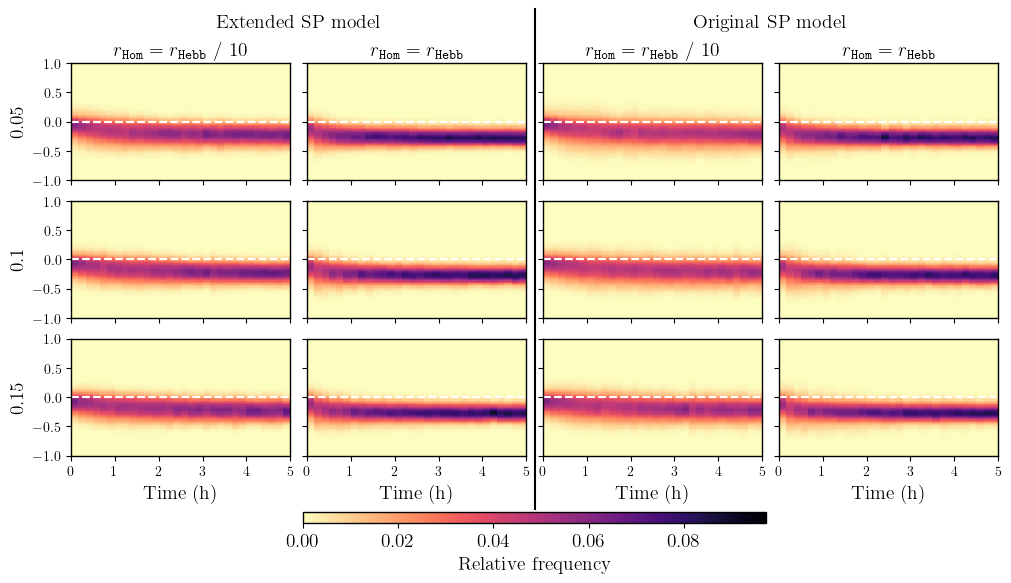

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sys


corr_intrapop_sync = read_figure_data("correlation_intrapop_sync_old_vs_new_SP")


def _load_and_prepare(variant, p_cross_pop0, Wmean, save_interval_min):
    """
    Return everything needed to draw one intra-pop correlation heatmap:
    bin edges [-1 ... 1] (101,), time-axis edges, time-axis label, and the
    same-pop histograms (n_histograms, 100), already normalized to relative
    frequency per histogram (see extract_figure_data.py).
    """
    df = corr_intrapop_sync
    sel = df[(df["variant"] == variant) & np.isclose(df["p_cross_pop0"], p_cross_pop0)
             & np.isclose(df["Wmean"], Wmean)].sort_values("histogram_index")
    bin_cols = [c for c in df.columns if c.startswith("[")]
    bin_edges = bin_edges_from_columns(bin_cols)
    C_same = sel[bin_cols].to_numpy()
    m = C_same.shape[0]

    # Time axis edges
    time_edges = np.arange(m + 1) * save_interval_min   # (m+1,) in minutes
    hours = time_edges[-1] / 60
    xlabel = "Time (min)" if hours <= 2 else "Time (h)"
    xdata = time_edges if hours <= 2 else time_edges / 60

    return bin_edges, xdata, xlabel, C_same


def plot_intra_pop_comparison_grid(
    p_cross_pop0_list, Wmean, columns, save_interval_min, cmap, color_scale="independent",
):
    """
    Build a len(p_cross_pop0_list)-by-len(columns) grid of intra-pop correlation
    heatmaps at a single Wmean value. One row per p_cross_pop0, one column per
    entry in `columns` (each a dict with 'variant', 'label', 'group'). Columns
    sharing the same 'group' get one bold title spanning them; a vertical dashed
    line separates consecutive columns whose group differs.

    color_scale: "independent" (each panel its own vmin/vmax — default),
                 "row"         (vmin/vmax shared across columns, per p_cross_pop0 row),
                 "all"         (one vmin/vmax shared across every panel in the figure)
    """
    n_rows = len(p_cross_pop0_list)
    n_cols = len(columns)

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.5 * n_cols, 1.8 * n_rows),
        sharex=True, sharey=True, squeeze=False, constrained_layout=True,
    )

    # Load everything first — needed up front if a shared color scale is requested
    grid_data = np.empty((n_rows, n_cols), dtype=object)
    for i, p_cross_pop0 in enumerate(p_cross_pop0_list):
        for j, col in enumerate(columns):
            bin_edges, xdata, xlabel, C_same = _load_and_prepare(
                col["variant"], p_cross_pop0, Wmean, save_interval_min
            )
            grid_data[i, j] = (bin_edges, xdata, xlabel, C_same)

    def limits_for(i):
        if color_scale == "independent":
            return None, None
        if color_scale == "row":
            C_group = [grid_data[i, k][3] for k in range(n_cols)]
        elif color_scale == "all":
            C_group = [grid_data[a, b][3] for a in range(n_rows) for b in range(n_cols)]
        else:
            raise ValueError(f"Unknown color_scale: {color_scale!r}")
        return min(np.nanmin(c) for c in C_group), max(np.nanmax(c) for c in C_group)

    meshes = np.empty((n_rows, n_cols), dtype=object)
    for i, p_cross_pop0 in enumerate(p_cross_pop0_list):
        vmin, vmax = limits_for(i)
        for j, col in enumerate(columns):
            bin_edges, xdata, xlabel, C_same = grid_data[i, j]
            ax = axes[i, j]
            mesh = ax.pcolormesh(
                xdata, bin_edges, C_same.T, cmap=cmap, shading="flat", vmin=vmin, vmax=vmax
            )
            meshes[i, j] = mesh

            ax.set_ylim(-1, 1)
            ax.set_xlim(0, 5)
            ax.axhline(0, color="white", linewidth=1.5, linestyle="--")

            if j == 0:
                ax.set_ylabel(f"{p_cross_pop0}", fontsize=f1)
            else:
                plt.setp(ax.get_yticklabels(), visible=False)

            if i == 0:
                ax.set_title(col["label"], fontsize=f1)

            if i == n_rows - 1:
                ax.set_xlabel(xlabel, fontsize=f1)
            else:
                plt.setp(ax.get_xticklabels(), visible=False)

    # Colorbar(s), matching the chosen color_scale
    if color_scale == "independent":
        for i in range(n_rows):
            for j in range(n_cols):
                fig.colorbar(meshes[i, j], ax=axes[i, j], pad=0.02, shrink=0.9)
    elif color_scale == "row":
        for i in range(n_rows):
            fig.colorbar(meshes[i, -1], ax=list(axes[i, :]), pad=0.02, shrink=0.9)
    else:  # "all"
        cbar = fig.colorbar(meshes[-1, -1], ax=axes, shrink=0.5, aspect=40, pad=0.02, orientation='horizontal', location='bottom')
        cbar.set_label('Relative frequency', fontsize=f1)
        cbar.ax.tick_params(labelsize=f1)

    # Group titles + a vertical dashed separator wherever the group changes.
    # Positions are read from the axes after layout has settled, so this must
    # run after all axes/colorbars above are in place.
    fig.canvas.draw()
    groups = [col["group"] for col in columns]
    y_top = max(axes[0, k].get_position().y1 for k in range(n_cols))
    y_bottom = min(axes[n_rows - 1, k].get_position().y0 for k in range(n_cols))
    j = 0
    while j < n_cols:
        g = groups[j]
        j_end = j
        while j_end + 1 < n_cols and groups[j_end + 1] == g:
            j_end += 1

        pos_left = axes[0, j].get_position()
        pos_right = axes[0, j_end].get_position()
        x_center = (pos_left.x0 + pos_right.x1) / 2
        fig.text(x_center, y_top + 0.06, g, ha="center", va="bottom",
                  fontsize=f1, fontweight="bold")

        if j_end + 1 < n_cols:
            pos_next = axes[0, j_end + 1].get_position()
            x_sep = (pos_right.x1 + pos_next.x0) / 2
            fig.add_artist(plt.Line2D([x_sep, x_sep], [y_bottom-0.1, 1.05], transform=fig.transFigure,
                                       color="black", linestyle="-", linewidth=1.5))
        j = j_end + 1

    return fig, axes


f1 = 14
mpl.rcParams['axes.linewidth'] = 1

columns = [
    dict(variant="HebHom3", label=r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$ / 10", group="Extended SP model"),
    dict(variant="HebHom2", label=r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",       group="Extended SP model"),
    dict(variant="Original1", label=r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$ / 10",   group="Original SP model"),
    dict(variant="Original",  label=r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",       group="Original SP model"),
]

fig, axes = plot_intra_pop_comparison_grid(
    p_cross_pop0_list=[0.05, 0.1, 0.150],
    Wmean=0.8,
    columns=columns,
    save_interval_min=10,
    cmap="magma_r",
    color_scale="all",   # switch to "row" or "all" for a shared color scale
)
fig.savefig("figures/correlation_intrapop_sync_old_vs_new_SP.jpeg",bbox_inches='tight', dpi=300)
plt.show()


## Time evolution of network measures during **synchronization**- dependence on the ratio of $r_\text{Hom}$ and $r_\text{Hebb}$ as well as initial inter-pop node degree density

## Sync state with both models of SP

Intra-pop node degree density (Pop 1, col 3), averaged over last 5 hours:
  HebHom3    p_cross_pop0=0.050  ->  0.1410
  HebHom3    p_cross_pop0=0.100  ->  0.1409
  HebHom3    p_cross_pop0=0.150  ->  0.1406
  HebHom2    p_cross_pop0=0.050  ->  0.1619
  HebHom2    p_cross_pop0=0.100  ->  0.1612
  HebHom2    p_cross_pop0=0.150  ->  0.1602
  Original   p_cross_pop0=0.050  ->  0.1613
  Original   p_cross_pop0=0.100  ->  0.1614
  Original   p_cross_pop0=0.150  ->  0.1610
  Original1  p_cross_pop0=0.050  ->  0.1387
  Original1  p_cross_pop0=0.100  ->  0.1390
  Original1  p_cross_pop0=0.150  ->  0.1385


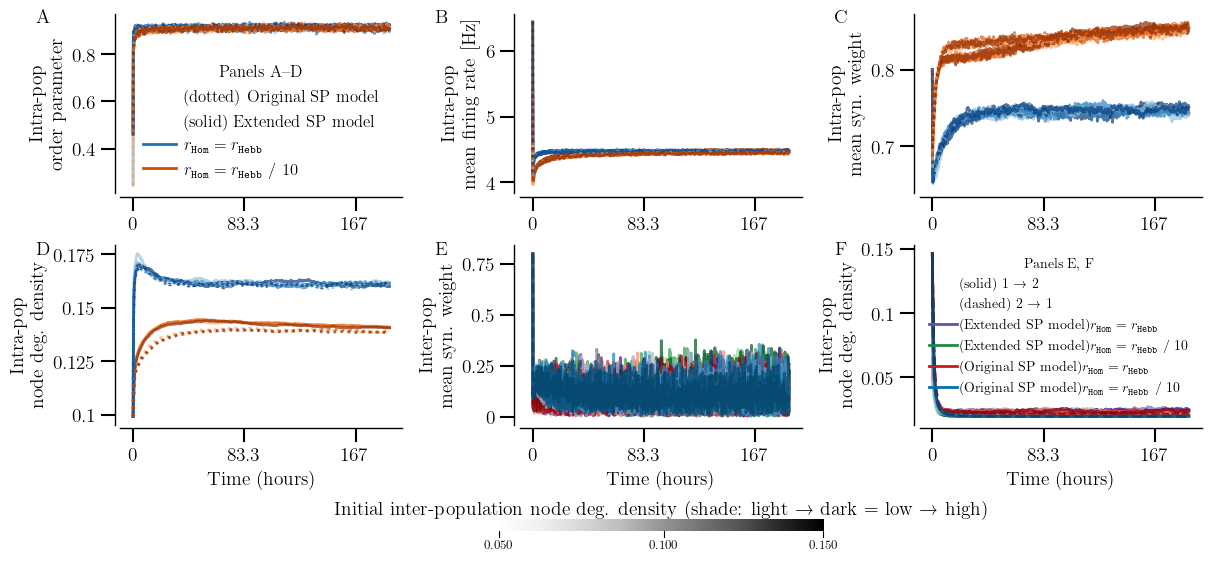

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase

class _NoHandle(HandlerBase):
    """Legend handler that draws nothing -- for text-only legend entries."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        a = Line2D([], [], linestyle='None', marker='None')
        a.set_visible(False)
        return [a]

N = 1024 # number of neurons
cmp = 'bwr'
lw = 2
s = 100
l1=1; f1=14; f2=12; f3=18  # the font sizes

folders = ["HebHom3", "HebHom2", "Original", "Original1"]  # SP-model variants, in plotting order
p_cross_pop_vals = [0.050, 0.100, 0.150]

folder_label = {
    "HebHom3": r"(Extended SP model)$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
    "HebHom2": r"(Extended SP model)$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "Original": r"(Original SP model)$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "Original1": r"(Original SP model)$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
}

# shade fraction sampled from each hue's colormap: light -> dark = low -> high p_cross_pop0
p_shade = {0.050: 0.40, 0.100: 0.68, 0.150: 0.95}

# --- intra-population panels (A-D): color = case (r_Hom=r_Hebb vs /10), shade = p_cross, -------
# --- ls = model (dotted = original SP, solid = extended SP); only Pop 1 is plotted --------------
folder_case = {"Original": "r_Hebb", "HebHom2": "r_Hebb", "Original1": "r_Hebb_10", "HebHom3": "r_Hebb_10"}
folder_model = {"Original": "original", "Original1": "original", "HebHom2": "extended", "HebHom3": "extended"}

case_cmap = {"r_Hebb": plt.cm.Blues, "r_Hebb_10": plt.cm.Oranges}
case_label = {
    "r_Hebb": r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "r_Hebb_10": r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$ / 10",
}
model_ls = {"original": ":", "extended": "-"}

# --- inter-population panels (E-F): color = folder (different hue set), shade = p_cross, ------
# --- linestyle = direction (solid = 1->2, dashed = 2->1) --------------------------------------
inter_folder_cmap = {
    "HebHom2": plt.cm.Purples,
    "HebHom3": plt.cm.Greens,
    "Original": plt.cm.Reds,
    "Original1": plt.cm.PuBu,
}
direction_ls = {"1→2": "-", "2→1": "--"}

traces = read_figure_data("spontaneous_sync_traces_old_vs_new_SP")

def load(fkey, p):
    return trace_array(traces, fkey, p)

data = {(fkey, p): load(fkey, p) for fkey in folders for p in p_cross_pop_vals}
hours_per_step = 10 / 60  # matches the x-axis formatter: hours = index * 10/60
n_steps_5h = round(5 / hours_per_step)  # = 30

print("Intra-pop node degree density (Pop 1, col 3), averaged over last 5 hours:")
for fkey in folders:
    for p in p_cross_pop_vals:
        d = data[(fkey, p)]
        avg_val = d[-n_steps_5h:, 3].mean()
        print(f"  {fkey:10s} p_cross_pop0={p:.3f}  ->  {avg_val:.4f}")

panel_labels = ["A", "B", "C", "D", "E", "F"]

fig = plt.figure(constrained_layout=True)
fig.set_size_inches(12, 5.5)
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 1,0.24])

# panels occupy rows 1-2 (2x3); row 0 is reserved for the title-like shade legend
axes = [plt.subplot(gs[row, col]) for row in range(0, 2) for col in range(3)]

top_specs = [
    ("Intra-pop \norder parameter",        {"Pop 1": 0}, "intra"),
    ("Intra-pop \nmean firing rate [Hz]",  {"Pop 1": 1}, "intra"),
    ("Intra-pop \nmean syn. weight",       {"Pop 1": 2}, "intra"),
]
bottom_specs = [
    ("Intra-pop \nnode deg. density", {"Pop 1": 3}, "intra"),
    ("Inter-pop \nmean syn. weight",  {"1→2": 9, "2→1": 11}, "inter"),
    ("Inter-pop \nnode deg. density", {"1→2": 10, "2→1": 12}, "inter"),
]

def draw_panel(ax, item_name, col_map, kind):
    plt.sca(ax)
    plot_prop(f1, ax)
    for fkey in folders:
        for p in p_cross_pop_vals:
            d = data[(fkey, p)]
            for lab, col in col_map.items():
                if kind == "intra":
                    color = case_cmap[folder_case[fkey]](p_shade[p])
                    ls = model_ls[folder_model[fkey]]
                else:
                    color = inter_folder_cmap[fkey](p_shade[p])
                    ls = direction_ls[lab]
                ax.plot(d[:, col], color=color, linestyle=ls, lw=lw, alpha = 0.7)
    ax.set_ylabel(item_name, fontsize=f1)
    # ax.set_xscale('symlog', linthresh=1)
    # ax.set_xlim(left=0)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x * 10 / 60:.3g}"))

for i, (item_name, col_map, kind) in enumerate(top_specs):
    ax = axes[i]
    draw_panel(ax, item_name, col_map, kind)
    ax.text(-0.3, 0.95, panel_labels[i], transform=ax.transAxes, fontsize=f1, fontweight='bold')

for j, (item_name, col_map, kind) in enumerate(bottom_specs):
    ax = axes[3 + j]
    draw_panel(ax, item_name, col_map, kind)
    ax.set_xlabel('Time (hours)', fontsize=f1)
    ax.text(-0.3, 0.95, panel_labels[3 + j], transform=ax.transAxes, fontsize=f1, fontweight='bold')

# ---------------- legend for Panels A-D: placed on Panel A -------------------------------------
model_handles = [
    Line2D([0], [0], color='none', label="(dotted) Original SP model"),
    Line2D([0], [0], color='none', label="(solid) Extended SP model"),
]
model_handler_map = {h: _NoHandle() for h in model_handles}

case_handles = [
    Line2D([0], [0], color=case_cmap["r_Hebb"](0.75), lw=lw, ls='-', label=case_label["r_Hebb"]),
    Line2D([0], [0], color=case_cmap["r_Hebb_10"](0.75), lw=lw, ls='-', label=case_label["r_Hebb_10"]),
]
ad_handles = model_handles + case_handles  # order matters: fills col-major -> col1 = model, col2 = case

panel_A = axes[0]
panel_A.legend(handles=ad_handles, handler_map=model_handler_map, loc='lower center',
               title="Panels A–D", fontsize=f2, title_fontsize=f2, frameon=False,
               ncol=1, columnspacing=1.0, handletextpad=0.5)

# ---------------- legend for Panels E, F: placed on Panel F -------------------------------------
direction_handles = [
    Line2D([0], [0], color='none', label="(solid) 1 → 2"),
    Line2D([0], [0], color='none', label="(dashed) 2 → 1"),
]
direction_handler_map = {h: _NoHandle() for h in direction_handles}

ef_folder_handles = [
    Line2D([0], [0], color=inter_folder_cmap["HebHom2"](0.75), lw=lw, ls='-', label=folder_label["HebHom2"]),
    Line2D([0], [0], color=inter_folder_cmap["HebHom3"](0.75), lw=lw, ls='-', label=folder_label["HebHom3"]),
    Line2D([0], [0], color=inter_folder_cmap["Original"](0.75), lw=lw, ls='-', label=folder_label["Original"]),
    Line2D([0], [0], color=inter_folder_cmap["Original1"](0.75), lw=lw, ls='-', label=folder_label["Original1"]),
]
ef_handles = direction_handles + ef_folder_handles

panel_F = axes[5]
panel_F.legend(handles=ef_handles, handler_map=direction_handler_map, loc='upper right',
               title="Panels E, F", fontsize=f2-2, title_fontsize=f2-2, frameon=False,
               ncol=1, columnspacing=1.0, handletextpad=0.2)

# ---------------- inter-population shade key: rendered like the figure title -------------------
lax_title = plt.subplot(gs[2, :])
lax_title.axis('off')
lax_title.set_xlim(0, 1)
lax_title.set_ylim(0, 1)

lax_title.text(0.5, 0.95, "Initial inter-population node deg. density  (shade: light → dark = low → high)",
                transform=lax_title.transAxes, ha='center', va='top', fontsize=f3 - 4, fontweight='bold')

shade_lo, shade_hi = p_shade[p_cross_pop_vals[0]], p_shade[p_cross_pop_vals[-1]]
gradient = np.linspace(shade_lo, shade_hi, 256).reshape(1, -1)
cax = lax_title.inset_axes([0.35, 0.05, 0.3, 0.45])
cax.imshow(gradient, aspect='auto', cmap=plt.cm.Greys, extent=[0, 1, 0, 1])
cax.set_xticks([])
cax.set_yticks([])
for spine in cax.spines.values():
    spine.set_visible(False)

for p in p_cross_pop_vals:
    x = (p_shade[p] - shade_lo) / (shade_hi - shade_lo)
    cax.plot([x, x], [0, -0.5], color='black', lw=0.8, clip_on=False)
    cax.annotate(f"{p:.3f}", xy=(x, -0.7), xycoords='data', ha='center', va='top',
                 fontsize=f2 - 3, annotation_clip=False)

plt.savefig("figures/spontaneous_sync_traces_old_vs_new_SP.jpeg", dpi=300)
plt.show()


## Time evolution of network measures during **desynchronization**- dependence on the ratio of $r_\text{Hom}$ and $r_\text{Hebb}$ as well as initial inter-pop node degree density

## Desync state with both models of SP

Intra-pop node degree density (Pop 1, col 3), averaged over last 5 hours:
  HebHom3    p_cross_pop0=0.050  ->  0.1036
  HebHom3    p_cross_pop0=0.100  ->  0.1026
  HebHom3    p_cross_pop0=0.150  ->  0.1029
  HebHom2    p_cross_pop0=0.050  ->  0.4580
  HebHom2    p_cross_pop0=0.100  ->  0.4575
  HebHom2    p_cross_pop0=0.150  ->  0.4583
  Original   p_cross_pop0=0.050  ->  0.4555
  Original   p_cross_pop0=0.100  ->  0.4564
  Original   p_cross_pop0=0.150  ->  0.4566
  Original1  p_cross_pop0=0.050  ->  0.0973
  Original1  p_cross_pop0=0.100  ->  0.0969
  Original1  p_cross_pop0=0.150  ->  0.0965


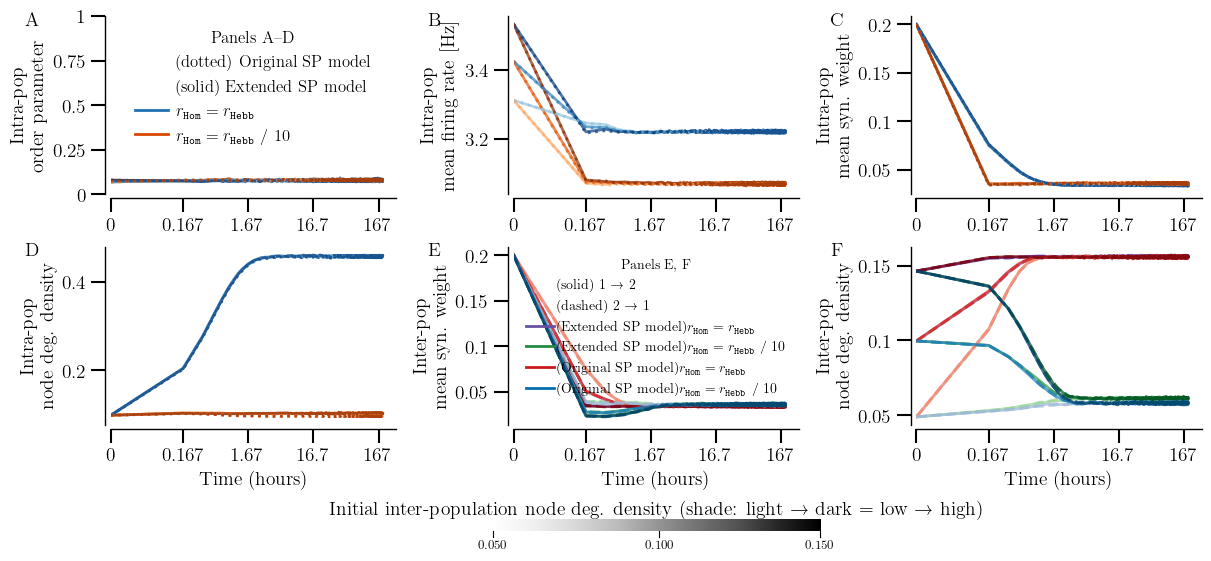

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase

class _NoHandle(HandlerBase):
    """Legend handler that draws nothing -- for text-only legend entries."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        a = Line2D([], [], linestyle='None', marker='None')
        a.set_visible(False)
        return [a]

N = 1024 # number of neurons
cmp = 'bwr'
lw = 2
s = 100
l1=1; f1=14; f2=12; f3=18  # the font sizes

folders = ["HebHom3", "HebHom2", "Original", "Original1"]  # SP-model variants, in plotting order
p_cross_pop_vals = [0.050, 0.100, 0.150]

folder_label = {
    "HebHom3": r"(Extended SP model)$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
    "HebHom2": r"(Extended SP model)$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "Original": r"(Original SP model)$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "Original1": r"(Original SP model)$r_\mathtt{Hom}= r_\mathtt{Hebb}$ / 10",
}

# shade fraction sampled from each hue's colormap: light -> dark = low -> high p_cross_pop0
p_shade = {0.050: 0.40, 0.100: 0.68, 0.150: 0.95}

# --- intra-population panels (A-D): color = case (r_Hom=r_Hebb vs /10), shade = p_cross, -------
# --- ls = model (dotted = original SP, solid = extended SP); only Pop 1 is plotted --------------
folder_case = {"Original": "r_Hebb", "HebHom2": "r_Hebb", "Original1": "r_Hebb_10", "HebHom3": "r_Hebb_10"}
folder_model = {"Original": "original", "Original1": "original", "HebHom2": "extended", "HebHom3": "extended"}

case_cmap = {"r_Hebb": plt.cm.Blues, "r_Hebb_10": plt.cm.Oranges}
case_label = {
    "r_Hebb": r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$",
    "r_Hebb_10": r"$r_\mathtt{Hom}=r_\mathtt{Hebb}$ / 10",
}
model_ls = {"original": ":", "extended": "-"}

# --- inter-population panels (E-F): color = folder (different hue set), shade = p_cross, ------
# --- linestyle = direction (solid = 1->2, dashed = 2->1) --------------------------------------
inter_folder_cmap = {
    "HebHom2": plt.cm.Purples,
    "HebHom3": plt.cm.Greens,
    "Original": plt.cm.Reds,
    "Original1": plt.cm.PuBu,
}
direction_ls = {"1→2": "-", "2→1": "--"}

traces = read_figure_data("spontaneous_desync_traces_old_vs_new_SP")

def load(fkey, p):
    return trace_array(traces, fkey, p)

data = {(fkey, p): load(fkey, p) for fkey in folders for p in p_cross_pop_vals}
hours_per_step = 10 / 60  # matches the x-axis formatter: hours = index * 10/60
n_steps_5h = round(5 / hours_per_step)  # = 30

print("Intra-pop node degree density (Pop 1, col 3), averaged over last 5 hours:")
for fkey in folders:
    for p in p_cross_pop_vals:
        d = data[(fkey, p)]
        avg_val = d[-n_steps_5h:, 3].mean()
        print(f"  {fkey:10s} p_cross_pop0={p:.3f}  ->  {avg_val:.4f}")

panel_labels = ["A", "B", "C", "D", "E", "F"]

fig = plt.figure(constrained_layout=True)
fig.set_size_inches(12, 5.5)
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 1,0.24])

# panels occupy rows 1-2 (2x3); row 0 is reserved for the title-like shade legend
axes = [plt.subplot(gs[row, col]) for row in range(0, 2) for col in range(3)]

top_specs = [
    ("Intra-pop \norder parameter",        {"Pop 1": 0}, "intra"),
    ("Intra-pop \nmean firing rate [Hz]",  {"Pop 1": 1}, "intra"),
    ("Intra-pop \nmean syn. weight",       {"Pop 1": 2}, "intra"),
]
bottom_specs = [
    ("Intra-pop \nnode deg. density", {"Pop 1": 3}, "intra"),
    ("Inter-pop \nmean syn. weight",  {"1→2": 9, "2→1": 11}, "inter"),
    ("Inter-pop \nnode deg. density", {"1→2": 10, "2→1": 12}, "inter"),
]

def draw_panel(ax, item_name, col_map, kind):
    plt.sca(ax)
    plot_prop(f1, ax)
    for fkey in folders:
        for p in p_cross_pop_vals:
            d = data[(fkey, p)]
            for lab, col in col_map.items():
                if kind == "intra":
                    color = case_cmap[folder_case[fkey]](p_shade[p])
                    ls = model_ls[folder_model[fkey]]
                else:
                    color = inter_folder_cmap[fkey](p_shade[p])
                    ls = direction_ls[lab]
                ax.plot(d[:, col], color=color, linestyle=ls, lw=lw, alpha=0.7)
    ax.set_ylabel(item_name, fontsize=f1)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(left=0)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x * 10 / 60:.3g}"))

for i, (item_name, col_map, kind) in enumerate(top_specs):
    ax = axes[i]
    draw_panel(ax, item_name, col_map, kind)
    if i == 0: ax.set_ylim(0,1)
    ax.text(-0.3, 0.95, panel_labels[i], transform=ax.transAxes, fontsize=f1, fontweight='bold')

for j, (item_name, col_map, kind) in enumerate(bottom_specs):
    ax = axes[3 + j]
    draw_panel(ax, item_name, col_map, kind)
    ax.set_xlabel('Time (hours)', fontsize=f1)
    ax.text(-0.3, 0.95, panel_labels[3 + j], transform=ax.transAxes, fontsize=f1, fontweight='bold')

# ---------------- legend for Panels A-D: placed on Panel A -------------------------------------
model_handles = [
    Line2D([0], [0], color='none', label="(dotted) Original SP model"),
    Line2D([0], [0], color='none', label="(solid) Extended SP model"),
]
model_handler_map = {h: _NoHandle() for h in model_handles}

case_handles = [
    Line2D([0], [0], color=case_cmap["r_Hebb"](0.75), lw=lw, ls='-', label=case_label["r_Hebb"]),
    Line2D([0], [0], color=case_cmap["r_Hebb_10"](0.75), lw=lw, ls='-', label=case_label["r_Hebb_10"]),
]
ad_handles = model_handles + case_handles  # order matters: fills col-major -> col1 = model, col2 = case

panel_A = axes[0]
panel_A.legend(handles=ad_handles, handler_map=model_handler_map, loc='upper center',
               title="Panels A–D", fontsize=f2, title_fontsize=f2, frameon=False,
               ncol=1, columnspacing=1.0, handletextpad=0.5)

# ---------------- legend for Panels E, F: placed on Panel F -------------------------------------
direction_handles = [
    Line2D([0], [0], color='none', label="(solid) 1 → 2"),
    Line2D([0], [0], color='none', label="(dashed) 2 → 1"),
]
direction_handler_map = {h: _NoHandle() for h in direction_handles}

ef_folder_handles = [
    Line2D([0], [0], color=inter_folder_cmap["HebHom2"](0.75), lw=lw, ls='-', label=folder_label["HebHom2"]),
    Line2D([0], [0], color=inter_folder_cmap["HebHom3"](0.75), lw=lw, ls='-', label=folder_label["HebHom3"]),
    Line2D([0], [0], color=inter_folder_cmap["Original"](0.75), lw=lw, ls='-', label=folder_label["Original"]),
    Line2D([0], [0], color=inter_folder_cmap["Original1"](0.75), lw=lw, ls='-', label=folder_label["Original1"]),
]
ef_handles = direction_handles + ef_folder_handles

panel_F = axes[4]
panel_F.legend(handles=ef_handles, handler_map=direction_handler_map, loc='upper center',
               title="Panels E, F", fontsize=f2-2, title_fontsize=f2-2, frameon=False,
               ncol=1, columnspacing=1.0, handletextpad=0.2)

# ---------------- inter-population shade key: rendered like the figure title -------------------
lax_title = plt.subplot(gs[2, :])
lax_title.axis('off')
lax_title.set_xlim(0, 1)
lax_title.set_ylim(0, 1)

lax_title.text(0.5, 0.95, "Initial inter-population node deg. density  (shade: light → dark = low → high)",
                transform=lax_title.transAxes, ha='center', va='top', fontsize=f3 - 4, fontweight='bold')

shade_lo, shade_hi = p_shade[p_cross_pop_vals[0]], p_shade[p_cross_pop_vals[-1]]
gradient = np.linspace(shade_lo, shade_hi, 256).reshape(1, -1)
cax = lax_title.inset_axes([0.35, 0.05, 0.3, 0.45])
cax.imshow(gradient, aspect='auto', cmap=plt.cm.Greys, extent=[0, 1, 0, 1])
cax.set_xticks([])
cax.set_yticks([])
for spine in cax.spines.values():
    spine.set_visible(False)

for p in p_cross_pop_vals:
    x = (p_shade[p] - shade_lo) / (shade_hi - shade_lo)
    cax.plot([x, x], [0, -0.5], color='black', lw=0.8, clip_on=False)
    cax.annotate(f"{p:.3f}", xy=(x, -0.7), xycoords='data', ha='center', va='top',
                 fontsize=f2 - 3, annotation_clip=False)

plt.savefig("figures/spontaneous_desync_traces_old_vs_new_SP.jpeg", dpi=300)
plt.show()


## Role of synaptic delay in pairwise spike correlation and synchronization

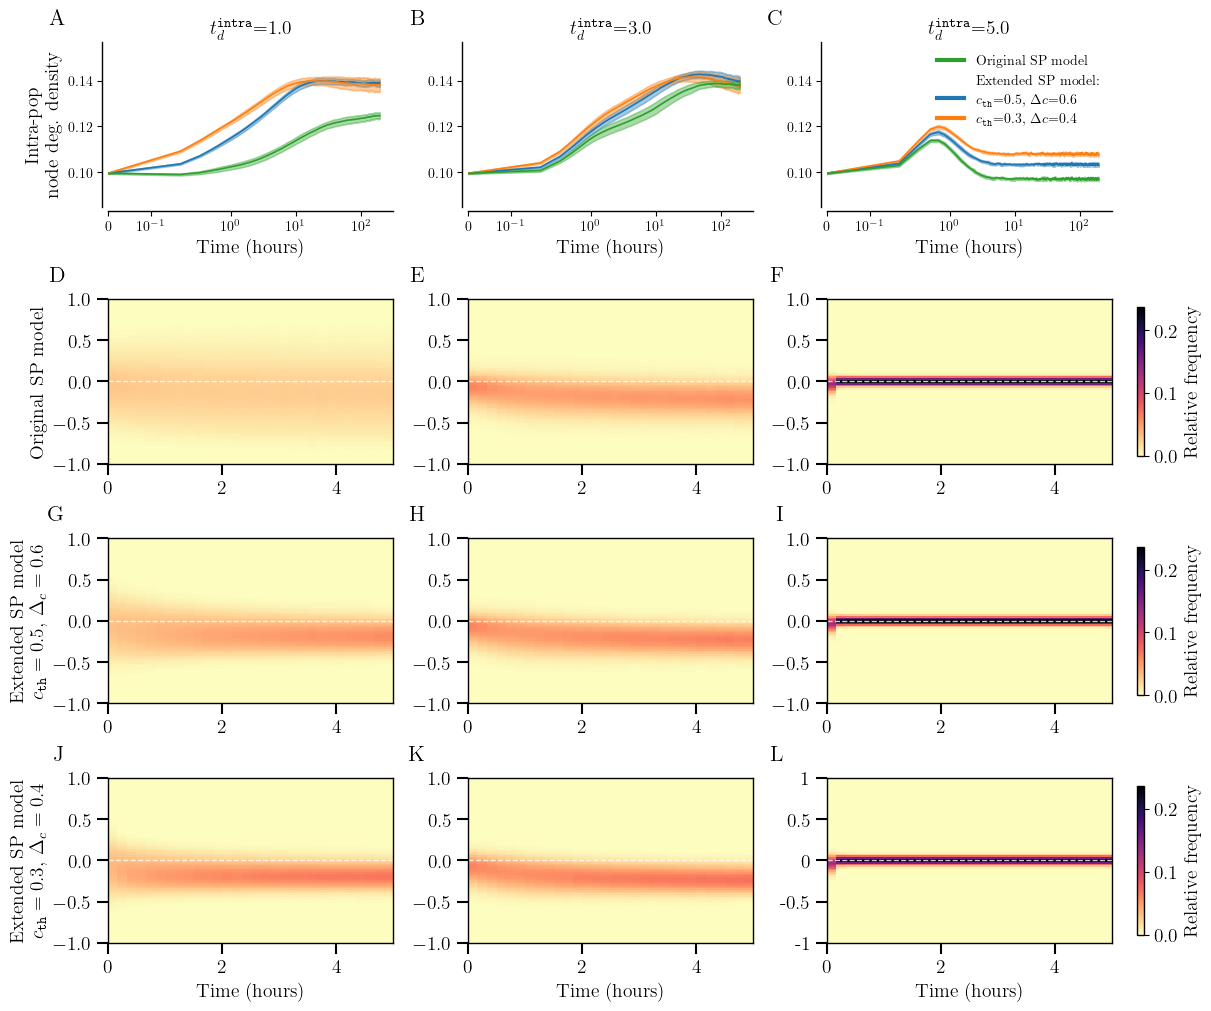

In [11]:
"""
Plots a trial-averaged summary figure across the corr_dep_add ON/OFF x
(corr_th0, delta_corr) x same_pop_delay conditions, from two prepared data files:

  figure_data/ndd_for_varying_td_intra_and_corr_dep_add_parameters_ndd.csv
      mean and std over 10 trials of the intra-pop node degree density (Pop 1)
      vs time (panels A-C)
  figure_data/ndd_for_varying_td_intra_and_corr_dep_add_parameters_corr_dist.csv
      trial-averaged intra-pop correlation distribution vs time (panels D-L)

See extract_figure_data.py for how both were obtained from the raw simulation output.
"""

import os
import matplotlib.ticker
mpl.rcParams['axes.linewidth'] = 1

CORR_DIST_SAVE_INTERVAL_MIN = 10   # minutes between saved correlation histograms
CORR_DIST_XLIM_HR = 5

corr_study_ndd = read_figure_data("ndd_for_varying_td_intra_and_corr_dep_add_parameters_ndd")
corr_study_corr_dist = read_figure_data("ndd_for_varying_td_intra_and_corr_dep_add_parameters_corr_dist")


def select_condition(df, corr_dep_add, corr_th0, delta_corr, same_pop_delay):
    return df[(df["corr_dep_add"] == corr_dep_add) & np.isclose(df["corr_th"], corr_th0)
              & np.isclose(df["delta_corr"], delta_corr) & np.isclose(df["same_pop_delay"], same_pop_delay)]


def load_ndd_mean_std(corr_dep_add, corr_th0, delta_corr, same_pop_delay):
    """Return (time_hr, mean, std) of the intra-pop node degree density (Pop 1) across trials."""
    sel = select_condition(corr_study_ndd, corr_dep_add, corr_th0, delta_corr, same_pop_delay)
    return sel["time_h"].to_numpy(), sel["ndd_intra_mean"].to_numpy(), sel["ndd_intra_std"].to_numpy()


def load_corr_dist(corr_dep_add, corr_th0, delta_corr, same_pop_delay,
                   save_interval_min=CORR_DIST_SAVE_INTERVAL_MIN):
    """Return (bin_edges, time_edges_hr, C_intra): the intra-pop ("same-pop") correlation
    histograms averaged over trials, normalized to relative frequency per row."""
    sel = select_condition(corr_study_corr_dist, corr_dep_add, corr_th0, delta_corr,
                           same_pop_delay).sort_values("histogram_index")
    bin_cols = [c for c in sel.columns if c.startswith("[")]
    C_intra = sel[bin_cols].to_numpy()
    time_edges_hr = np.arange(C_intra.shape[0] + 1) * save_interval_min / 60.0
    return bin_edges_from_columns(bin_cols), time_edges_hr, C_intra


def plot_summary_figure(cmap="magma_r", save_path=None):
    """One 4x3 figure, one column per same_pop_delay in [1, 3, 5].

    Row 1 (line plots, mean +/- trial-std band): intra-pop node degree
    density vs time, comparing corr-dep-add=ON at (corr_th0,delta_corr)=
    (0.5,0.6) and (0.3,0.4) against corr-dep-add=OFF (corr_th0/delta_corr
    fixed at 0.5/0.6 only to pick a file; they don't affect OFF dynamics).

    Rows 2-4 (heatmaps, averaged over trials; each row has
    its own color scale and its own colorbar): intra-pop correlation
    distribution vs time (first CORR_DIST_XLIM_HR hours), one row per
    condition:
      Row 2: corr-dep-add=OFF, corr_th0=0.5, delta_corr=0.6 (original SP model)
      Row 3: corr-dep-add=ON,  corr_th0=0.5, delta_corr=0.6
      Row 4: corr-dep-add=ON,  corr_th0=0.3, delta_corr=0.4
    """
    same_pop_delays = [1, 3, 5]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_on1, color_on2, color_off = colors[0], colors[1], colors[2]

    f1, f2, f3 = 14, 10, 16  # tick/axis-label, legend, title font sizes

    fig = plt.figure(constrained_layout=True)
    fig.set_size_inches(12, 10)
    gs = gridspec.GridSpec(4, 3, figure=fig)
    axes = [[fig.add_subplot(gs[row, col]) for col in range(3)] for row in range(4)]

    # Shared legend for the top row (identical conditions in every column).
    # "Extended SP model:" is a header row with no visible handle; the two ON
    # cases are listed under it, indented with leading spaces.
    legend_handles = [
        Line2D([], [], color=color_off),
        Line2D([], [], color="none"),
        Line2D([], [], color=color_on1),
        Line2D([], [], color=color_on2),
    ]
    legend_labels = [
        "Original SP model",
        "Extended SP model:",
        r"   $c_\mathtt{th}$=0.5, $\Delta c$=0.6",
        r"   $c_\mathtt{th}$=0.3, $\Delta c$=0.4",
    ]

    # --- Row 1: intra-pop node degree density vs time ---
    panel_labels = ["A","B","C"]
    panel_conditions = [
        ("ON", 0.5, 0.6, color_on1),
        ("ON", 0.3, 0.4, color_on2),
        ("OFF", 0.5, 0.6, color_off),
    ]
    row0_axes = []
    for col, spd in enumerate(same_pop_delays):
        ax = axes[0][col]
        linthresh = None
        for cda, cth0, dcorr, color in panel_conditions:
            time_hr, mean, std = load_ndd_mean_std(cda, cth0, dcorr, spd)
            if linthresh is None:
                linthresh = time_hr[time_hr > 0].min()
            ax.plot(time_hr, mean, color=color,lw=1.2)
            ax.fill_between(time_hr, mean - std, mean + std, color=color, alpha=0.4)
        ax.set_xscale("symlog", linthresh=linthresh)
        ax.set_xlim(left=0)
        ax.set_title(r"$t_d^\mathtt{intra}$=%.1f" % spd, fontsize=f1)
        ax.set_xlabel("Time (hours)", fontsize=f1)
        ax.text(-0.15, 1.2, "%s"%(panel_labels[col]), transform=ax.transAxes, fontsize=f3, fontweight="bold", va="top", ha="right")
        plot_prop(f1, ax)
        ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
        if col == 0:
            ax.set_ylabel("Intra-pop \nnode deg. density", fontsize=f1)
        if col == 2:
            ax.legend(legend_handles, legend_labels, fontsize=f2, loc="upper right", frameon=False)
        
        row0_axes.append(ax)


    # Match y-scale across the three columns (each was autoscaled independently above).
    ymin = min(ax.get_ylim()[0] for ax in row0_axes)-0.01
    ymax = max(ax.get_ylim()[1] for ax in row0_axes)+0.01
    for ax in row0_axes:
        ax.set_ylim(ymin, ymax)

    # --- Rows 2-4: intra-pop correlation distribution vs time, one row per condition ---
    corr_dist_conditions = [
        ("OFF", 0.5, 0.6, "Original SP model"),
        ("ON", 0.5, 0.6, r"Extended SP model" "\n" r"$c_\mathtt{th}=0.5$, $\Delta_c=0.6$"),
        ("ON", 0.3, 0.4, r"Extended SP model" "\n" r"$c_\mathtt{th}=0.3$, $\Delta_c=0.4$"),
    ]

    row_panel_labels = [["D","E","F"], ["G","H","I"], ["J","K","L"]]

    for row_idx, (cda, cth0, dcorr, row_ylabel) in enumerate(corr_dist_conditions):
        row = row_idx + 1
        panel_labels = row_panel_labels[row_idx]

        corr_rows_data = []
        vmin, vmax = np.inf, -np.inf
        for spd in same_pop_delays:
            bin_edges, time_edges_hr, C_intra = load_corr_dist(cda, cth0, dcorr, spd)
            corr_rows_data.append((bin_edges, time_edges_hr, C_intra))
            vmin = min(vmin, np.nanmin(C_intra))
            vmax = max(vmax, np.nanmax(C_intra))

        row_axes = []
        last_mesh = None
        for col, (spd, (bin_edges, time_edges_hr, C_intra)) in enumerate(zip(same_pop_delays, corr_rows_data)):
            ax = axes[row][col]
            last_mesh = ax.pcolormesh(time_edges_hr, bin_edges, C_intra.T, cmap=cmap,
                                       shading="flat", vmin=vmin, vmax=vmax)
            ax.set_ylim(-1, 1)
            ax.set_xlim(0, CORR_DIST_XLIM_HR)
            ax.axhline(0, color="white", linewidth=1, linestyle="--", alpha=0.8)
            ax.tick_params(direction='out', which='major', length=8, width=1.5, colors='k', labelsize=f1)
            ax.text(-0.15, 1.2, "%s"%(panel_labels[col]), transform=ax.transAxes, fontsize=f3, fontweight="bold", va="top", ha="right")
            if row == 3:  # only the bottom-most row gets an x-axis label
                ax.set_xlabel("Time (hours)", fontsize=f1)
            if col == 0:
                ax.set_ylabel(row_ylabel, fontsize=f1)
            row_axes.append(ax)

        cbar = fig.colorbar(last_mesh, ax=row_axes, fraction=0.02, pad=0.02, shrink=0.9, label="Relative frequency")
        cbar.set_label('Relative frequency', fontsize=f1)
        cbar.ax.tick_params(labelsize=f1)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, axes



if __name__ == "__main__":
    plot_summary_figure(save_path = "figures/ndd_for_varying_td_intra_and_corr_dep_add_parameters.jpeg")
    plt.show()
